In [13]:
# imports
import numpy as np
import pickle
import matplotlib.pyplot as plt

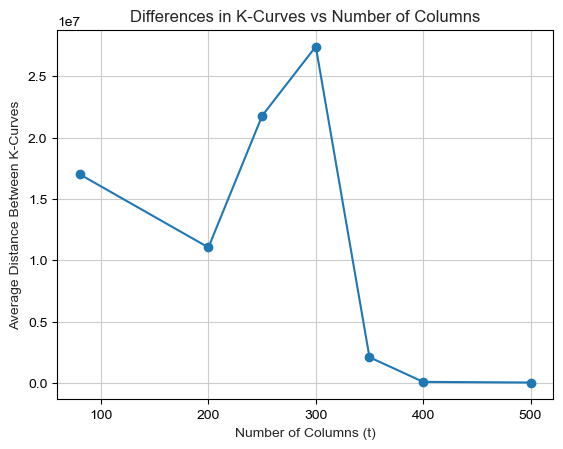

In [14]:
# plot t v number of endpoints

# first get all the data
t = [80, 200, 250, 300, 350, 400, 500]
cost_factors = [200, 500, 1000, 2000, 3000, 4000, 5000, 10000, 100000, 1000000]
final_costs = []
# [Kjs, m_0, final_cost, m_values] 

endpoints = [[] * len(cost_factors) for i in range(len(cost_factors))]
k_curves = [[] * len(t) for _ in range(len(t))]

filenames = ['lower_bound_7_higher_cost_t_80_curves.pickle',
              'lower_bound_7_higher_cost_t_200_curves.pickle',
              'lb7_200_1m_t_250.pickle',
              'lb7_200_1m_t_300.pickle',
              'lb7_200_1m_t_350.pickle',
              'lb7_200_1m_t_400.pickle',
              'lower_bound_7_higher_cost_t_500_curves.pickle']

# for each file
for i, filename in enumerate(filenames):
    with open(filename, 'rb') as f:
        data = pickle.load(f)
        
        # int_end = []
        # # get the endpoints for each cost factor
        # for item in data:
        #     int_end.append(item[3][-1])
        
        # to collate k curves
        for item in data:
            k_curves[i].append(item[0])
            
        # array of final costs
        costs = []
            
        # iterate through the different cost factors
        for i in range(len(data)):
            # for each cost factor at this current t
            # append the endpoint
            endpoints[i].append(data[i][3][-1])
            
            # also append the final cost
            costs.append(data[i][2])
        
        # append the final costs for this t
        final_costs.append(costs)

# plot the data
# plt.figure(figsize=(10, 6))
# plt.title('Number of Endpoints vs Number of Columns')
# plt.xlabel('t')
# plt.ylabel('Number of Endpoints')
# # plot each cost factor
# for i in range(len(cost_factors)):
#     plt.plot(t, endpoints[i], label=f'Cost Factor: {cost_factors[i]}')
# plt.legend()
# plt.xticks(t)
# # Get current axis
# ax = plt.gca()
# ax.tick_params(axis='x', which='major', bottom=True)
# ax.tick_params(axis='y', which='major', left=True)
# # Set all spines (box edges) to black
# for spine in ax.spines.values():
#     spine.set_color('black')
# # Set tick parameters to black
# ax.tick_params(axis='both', colors='black')
# ax.grid(True)
# # Display the plot
# plt.show()

# to find which t makes the most distinct curves
def average_curve_distance(K_curves):
    total = 0   # keep track of cumulative distance between curves
    count = 0   # how many curves we have compared
    for i in range(len(K_curves)):
        for j in range(i + 1, len(K_curves)):
            diff = np.linalg.norm(K_curves[i] - K_curves[j])    # difference between two curves
            total += diff
            count += 1
    return total / count    # average distance between curves

avg_distances = [average_curve_distance(k_curves[t_value]) for t_value in range(len(t))]

plt.plot(t, avg_distances, marker='o')
plt.xlabel("Number of Columns (t)")
plt.ylabel("Average Distance Between K-Curves")
plt.title("Differences in K-Curves vs Number of Columns")
ax = plt.gca()
ax.tick_params(axis='x', which='major', bottom=True)
ax.tick_params(axis='y', which='major', left=True)
# Set all spines (box edges) to black
for spine in ax.spines.values():
    spine.set_color('black')
# Set tick parameters to black
ax.tick_params(axis='both', colors='black')
ax.grid(True)
plt.show()




In [15]:
# print the cost of each curve
for i in range(len(t)):
    print(f"Final costs for t = {t[i]} : {final_costs[i]}")

Final costs for t = 80 : [81070907.53379278, 202677254.8220875, 405354537.6429569, 810706325.685857, 1216063528.8850355, 1621410239.7949862, 1986718583.807519, 1986718583.807519, 1986718583.807519, 1986718583.807519]
Final costs for t = 200 : [104217383.47095364, 260543737.14692017, 521086620.97336584, 1042157389.3668159, 1362241862.796791, 1362241862.796791, 1362241862.796791, 1362241862.796791, 1362241862.796791, 1362241862.796791]
Final costs for t = 250 : [109946387.60184607, 274866451.5811126, 549732977.3804091, 1099463041.6089869, 1649197977.417374, 2198930107.8505735, 2386044051.055743, 2386044051.055743, 2386044051.055743, 2386044051.055743]
Final costs for t = 300 : [114645918.08134674, 286614806.87677693, 573201762.6243813, 1146452976.009073, 1719661159.2687652, 2290862906.3836036, 2860450311.5863504, 3021405734.8318853, 3021405734.8318853, 3021405734.8318853]
Final costs for t = 350 : [118629553.29520673, 296575577.7547688, 493255424.4281695, 493255424.4281695, 493255424.428